# Import Libraries

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.preprocessing import LabelEncoder

# Load Dataset

In [2]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Dataset Information

In [3]:
print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

print("\n")

print("="*60)
print("Missing Values")
print("="*60)

print(df.isnull().sum())

print("\n")

print("="*60)
print("Statistical Summary")
print("="*60)

df.describe()

Dataset Shape
(545, 13)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


Missing Values
price               0
area                0
bedrooms            0
bathrooms           0
sto

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


# Data Preprocessing

In [4]:
encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


# Correlation Heatmap

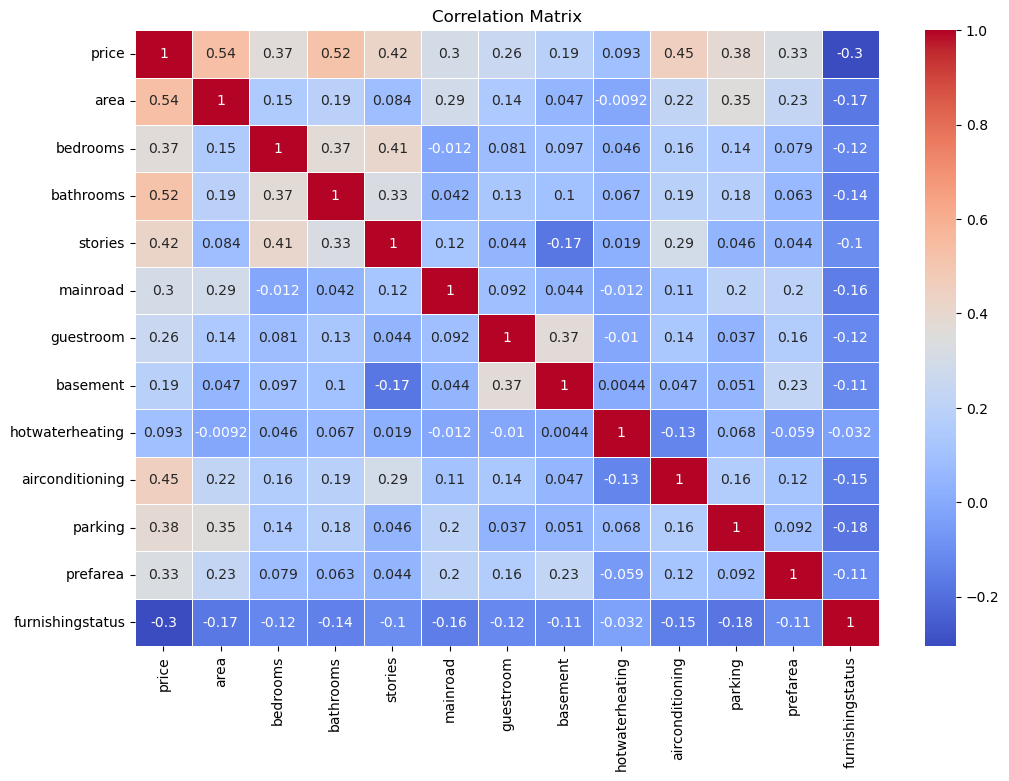

In [5]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

# Feature Selection

In [6]:
X = df.drop("price", axis=1)

y = df["price"]

print(X.shape)
print(y.shape)

(545, 12)
(545,)


# Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (436, 12)
Testing Data : (109, 12)


# Build Linear Regression Model

In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


# Predictions

In [9]:
y_pred = model.predict(X_test)

prediction = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

prediction.head(10)

,Actual Price,Predicted Price
316,4060000,5.203692e+06
77,6650000,7.257004e+06
360,3710000,3.062829e+06
90,6440000,4.559592e+06
493,2800000,3.332932e+06
209,4900000,3.563081e+06
176,5250000,5.645466e+06
249,4543000,6.413980e+06
516,2450000,2.755832e+06
426,3353000,2.668939e+06


# Model Evaluation

In [10]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("="*50)

print("Model Performance")

print("="*50)

print(f"Mean Absolute Error : {mae:.2f}")

print(f"Mean Squared Error  : {mse:.2f}")

print(f"Root Mean Squared Error : {rmse:.2f}")

print(f"R2 Score : {r2:.4f}")

Model Performance
Mean Absolute Error : 979679.69
Mean Squared Error  : 1771751116594.03
Root Mean Squared Error : 1331071.42
R2 Score : 0.6495


# Actual vs Predicted Plot

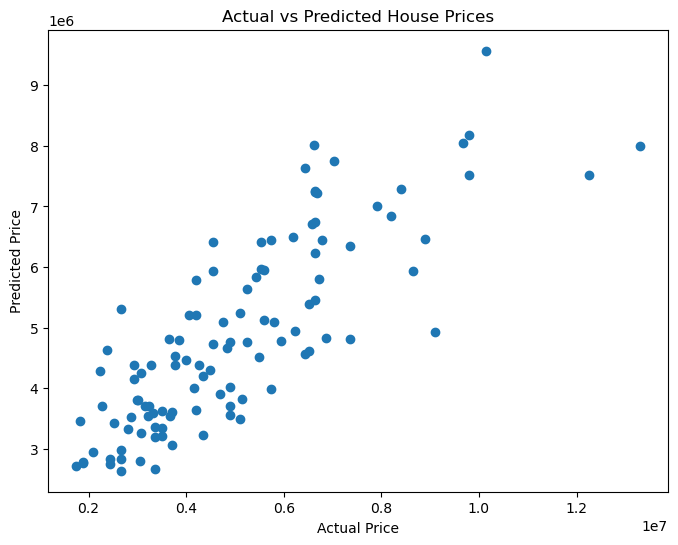

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

# Residual Plot

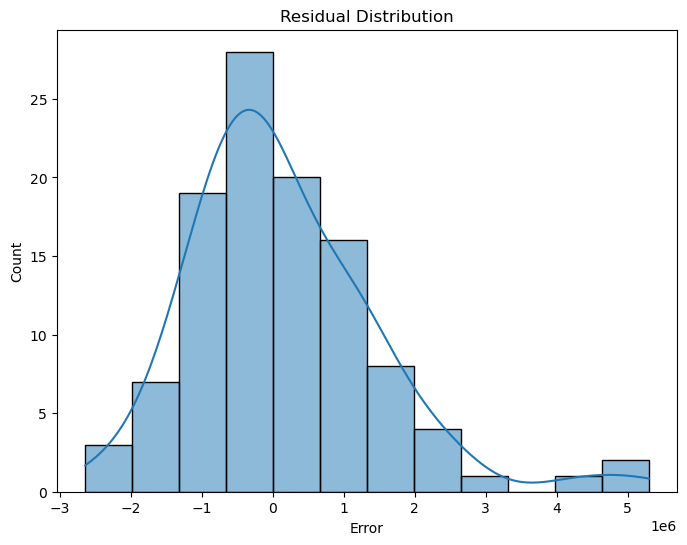

In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.xlabel("Error")

plt.show()

# Feature Importance (Coefficients)

In [13]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
2,bathrooms,1.097117e+06
8,airconditioning,7.855506e+05
7,hotwaterheating,6.878813e+05
10,prefarea,6.299017e+05
3,stories,4.062232e+05
6,basement,3.931598e+05
4,mainroad,3.668242e+05
5,guestroom,2.331468e+05
9,parking,2.257565e+05
1,bedrooms,7.857449e+04


# Simple Linear Regression

In [14]:
X_simple = df[["area"]]

y_simple = df["price"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y_simple,
    test_size=0.20,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train_s, y_train_s)

pred_simple = simple_model.predict(X_test_s)

print("Simple Linear Regression R2 Score")

print(r2_score(y_test_s, pred_simple))

Simple Linear Regression R2 Score
0.27287851871974644


# Regression Line

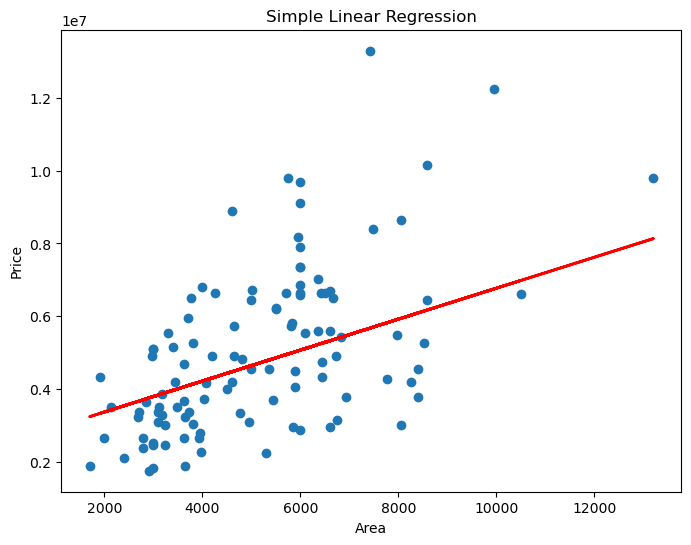

In [15]:


plt.figure(figsize=(8,6))

plt.scatter(X_test_s, y_test_s)

plt.plot(X_test_s,
         pred_simple,
         color="red",
         linewidth=2)

plt.xlabel("Area")

plt.ylabel("Price")

plt.title("Simple Linear Regression")

plt.show()

# Conclusion

In [17]:
print("="*60)

print("Project Completed Successfully")

print("="*60)

print("""
Summary

1. Loaded Housing Dataset

2. Encoded categorical features

3. Performed Exploratory Data Analysis

4. Trained Simple Linear Regression

5. Trained Multiple Linear Regression

6. Evaluated using:
   • MAE
   • MSE
   • RMSE
   • R² Score

7. Visualized Predictions

8. Interpreted Feature Coefficients
""")

Project Completed Successfully

Summary

1. Loaded Housing Dataset

2. Encoded categorical features

3. Performed Exploratory Data Analysis

4. Trained Simple Linear Regression

5. Trained Multiple Linear Regression

6. Evaluated using:
   • MAE
   • MSE
   • RMSE
   • R² Score

7. Visualized Predictions

8. Interpreted Feature Coefficients

